In [174]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cafe_sales.csv")
df_ORI=df.copy()

# Preview data
df.head()

,Unnamed: 0,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,2,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,4,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,5,TXN_7034554,Salad,2,5.0,10.0,DK/NS,DK/NS,2023-04-27
4,6,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [175]:
print("After reviewing the original dirty dataset, \n" \
"both the Transaction Date and the Transaction ID 'DOES NOT' follow a fixed sequential order. \n" \
"Forward-filling or backward-filling missing dates would introduce incorrect timestamps and \n" \
"are unsuitable options for repairing DK/NS dates in this dataset\n")

# Remove DK/NS from Items
df = df.dropna(subset=["Transaction Date"]).copy()
removed = len(df_ORI) - len(df)

print(f"** Dropped {removed} rows ({removed/len(df)*100:.2f}%) due to NaT in Transaction Date. Sample Size: {len(df)} **")

After reviewing the original dirty dataset, 
both the Transaction Date and the Transaction ID 'DOES NOT' follow a fixed sequential order. 
Forward-filling or backward-filling missing dates would introduce incorrect timestamps and 
are unsuitable options for repairing DK/NS dates in this dataset

** Dropped 460 rows (4.84%) due to NaT in Transaction Date. Sample Size: 9505 **


In [176]:
print(df["Transaction Date"].dtype)
df["Transaction Date"] = df["Transaction Date"].str.strip()
df["Transaction Date"] = df["Transaction Date"].str.extract(r"(\d{4}-\d{2}-\d{2})")

df["Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
print(df["Date"].dtype)

df["Month"] = df["Date"].dt.month_name()
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

df.loc[1:3, "Transaction Date":]


object
datetime64[ns]


,Transaction Date,Date,Month
1,2023-05-16,2023-05-16,May
2,2023-07-19,2023-07-19,July
3,2023-04-27,2023-04-27,April


In [181]:
#df["Item"].value_counts()

item_cat_map = {
    "Coffee": "Drink",
    "Tea": "Drink",
    "Juice": "Drink",
    "Smoothie": "Drink",
    "Salad": "Food",
    "Cookie": "Food",
    "Cake": "Food",
    "Sandwich": "Food"
}
item_subcat_map = {
    "Coffee": "Hot Drink",
    "Tea": "Hot Drink",
    "Juice": "Cold Drink",
    "Smoothie": "Cold Drink",
    "Salad": "Meal",
    "Sandwich": "Meal",
    "Cookie": "Treat",
    "Cake": "Treat"
}
df["Item Category"] = df["Item"].map(item_cat_map)
df["Item Sub Category"] = df["Item"].map(item_subcat_map)

df.head()

,Unnamed: 0,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Date,Month,Item Category,Item Sub Category
0,0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023-09-08,September,Drink,Hot Drink
1,2,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,2023-05-16,May,Food,Treat
2,4,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,2023-07-19,July,Food,Treat
3,5,TXN_7034554,Salad,2,5.0,10.0,DK/NS,DK/NS,2023-04-27,2023-04-27,April,Food,Meal
4,6,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023-06-11,June,Drink,Hot Drink


C:\Users\ann81\AppData\Local\Temp\ipykernel_23220\651268411.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_total = df.groupby("Month")["Total Spent"].sum()
C:\Users\ann81\AppData\Local\Temp\ipykernel_23220\651268411.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_cat = df.groupby(["Month", "Item Category"])["Total Spent"].sum().unstack()
C:\Users\ann81\AppData\Local\Temp\ipykernel_23220\651268411.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

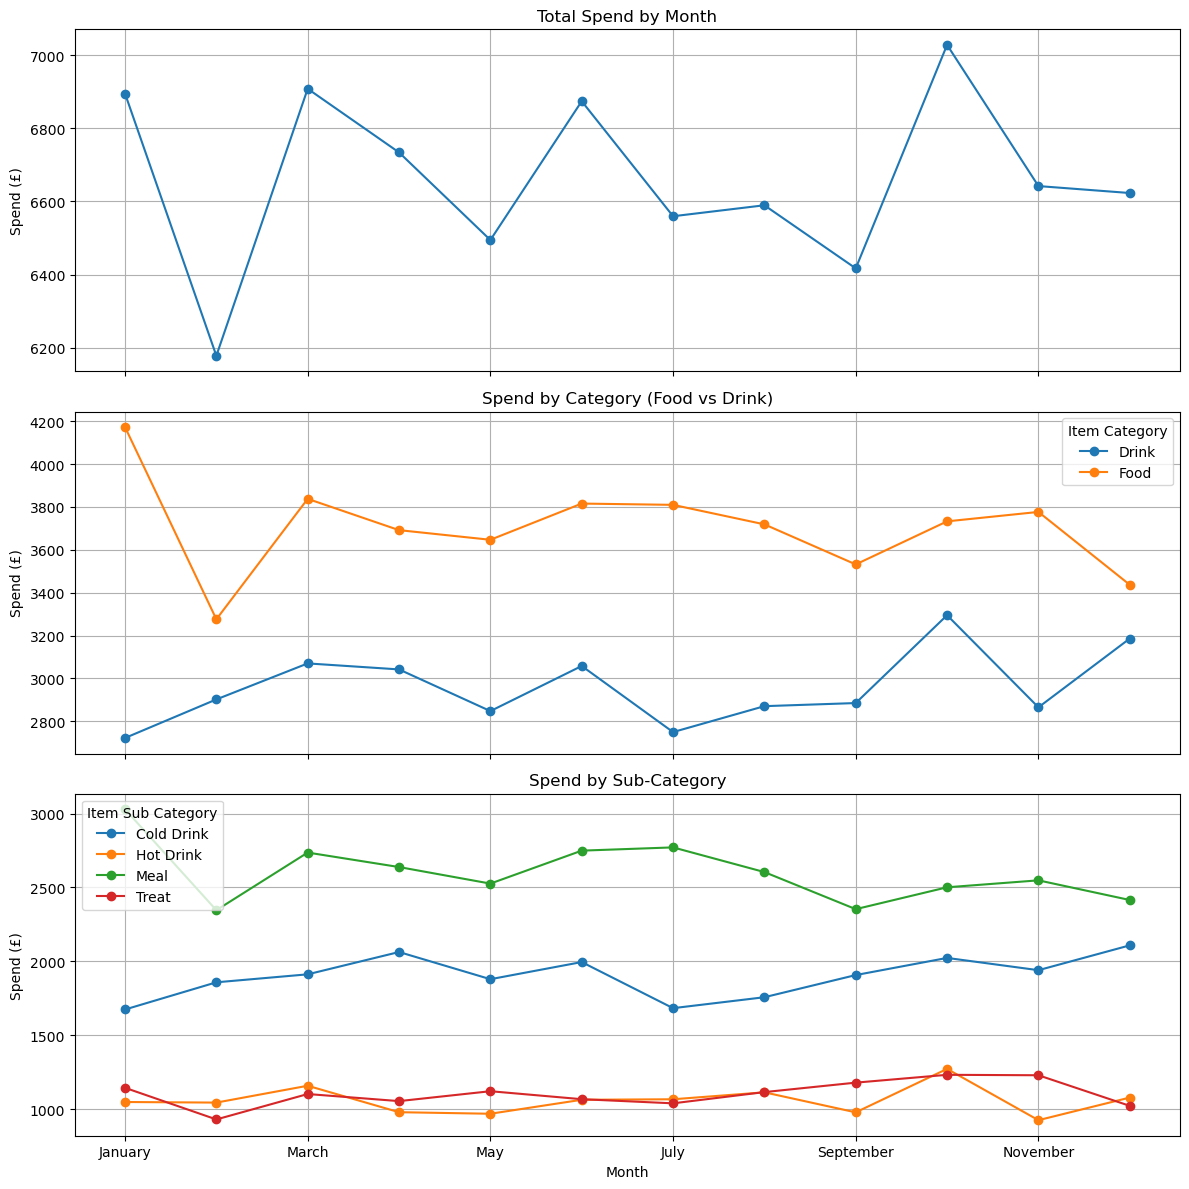

In [ ]:
# definitions
monthly_total = df.groupby("Month")["Total Spent"].sum()
monthly_cat = df.groupby(["Month", "Item Category"])["Total Spent"].sum().unstack()
monthly_subcat = df.groupby(["Month", "Item Sub Category"])["Total Spent"].sum().unstack()

#layout: 3‑row subplot
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

#1: Total Spend
monthly_total.plot(ax=axes[0], kind="line", marker="o")
axes[0].set_title("Total Spend by Month")
axes[0].set_ylabel("Spend (£)")
axes[0].grid(True)

#2: Category Spend
monthly_cat.plot(ax=axes[1], kind="line", marker="o")
axes[1].set_title("Spend by Category (Food vs Drink)")
axes[1].set_ylabel("Spend (£)")
axes[1].grid(True)

#3: Sub‑Category Spend
monthly_subcat.plot(ax=axes[2], kind="line", marker="o")
axes[2].set_title("Spend by Sub‑Category")
axes[2].set_ylabel("Spend (£)")
axes[2].grid(True)

plt.xlabel("Month")
plt.tight_layout()
plt.show()

C:\Users\ann81\AppData\Local\Temp\ipykernel_23220\4128367906.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_total = df.groupby("Month")["Total Spent"].sum()
C:\Users\ann81\AppData\Local\Temp\ipykernel_23220\4128367906.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Month", "Item Category"])["Total Spent"]
C:\Users\ann81\AppData\Local\Temp\ipykernel_23220\4128367906.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

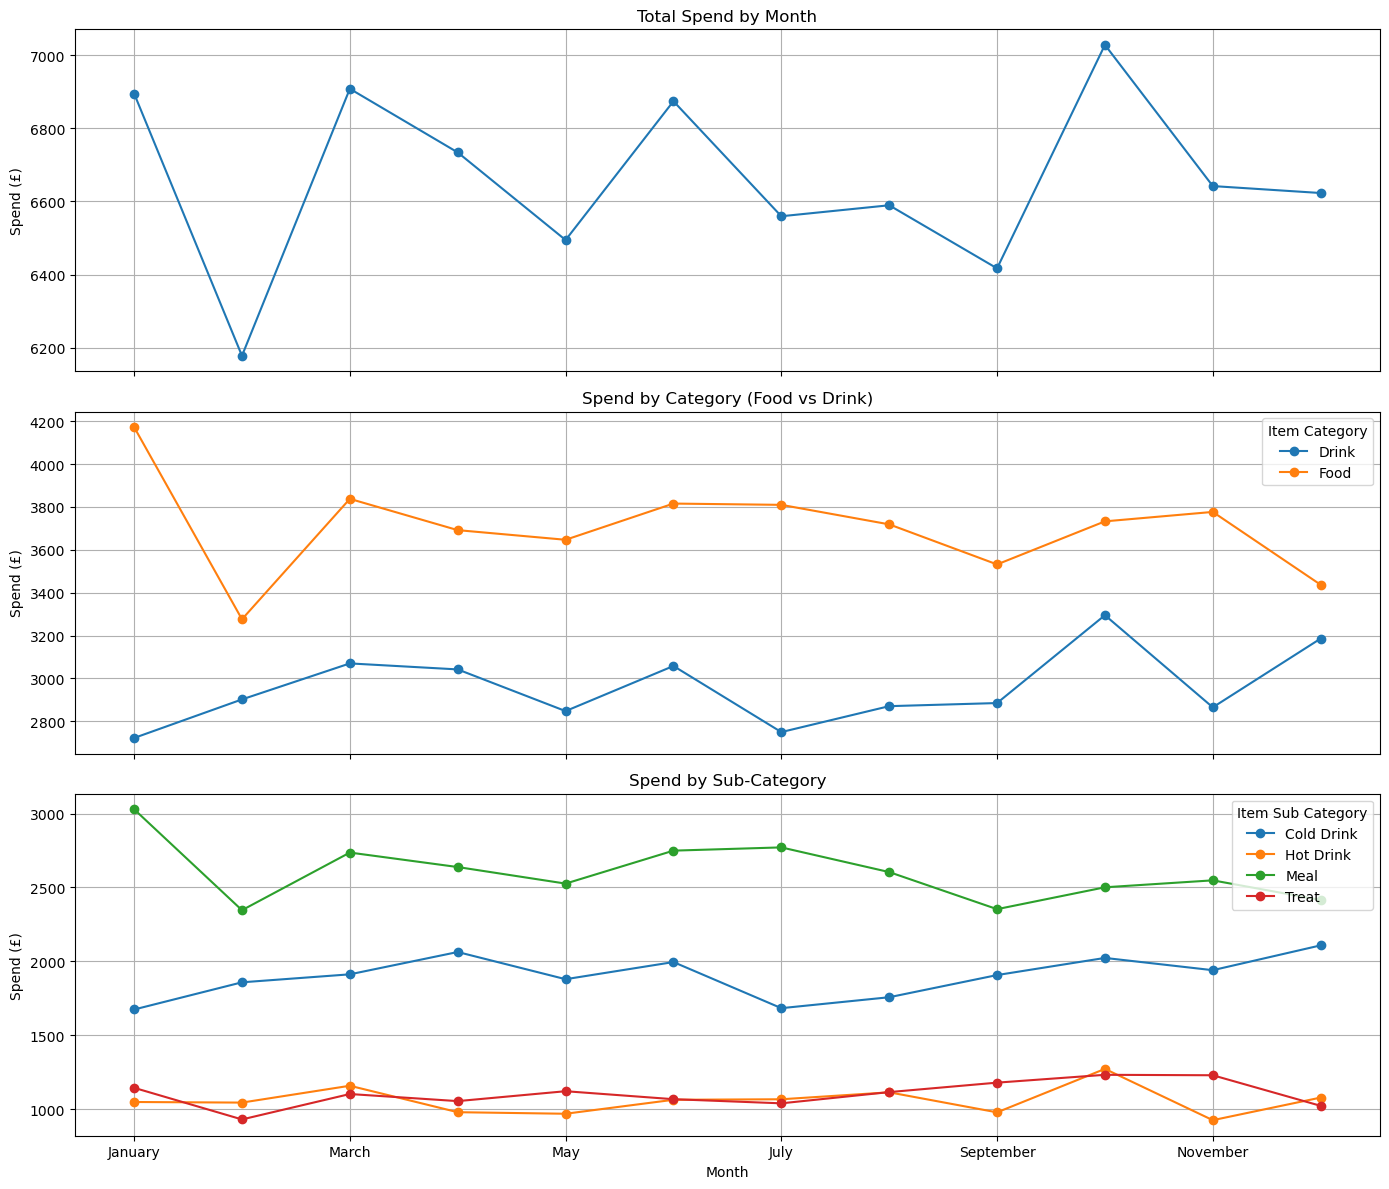